# Analisis Data NO₂ Kecamatan Kalianget Berdasarkan Sentinel-5P Tahun 2025–2026

## 1. Business Understanding

### 1.1 Latar Belakang

Kualitas udara merupakan salah satu bagian penting dari kondisi lingkungan yang perlu diperhatikan. Salah satu polutan yang dapat digunakan untuk melihat kondisi atmosfer adalah Nitrogen Dioxide (NO₂).

Pada tugas sebelumnya, data polutan diambil pada wilayah Kabupaten Sumenep dengan beberapa parameter polutan. Pada tugas sekarang, wilayah pengamatan dipersempit menjadi Kecamatan Kalianget dan polutan yang digunakan hanya NO₂.

Data NO₂ diperoleh dari satelit Sentinel-5P melalui platform openEO. Data kemudian diolah menjadi data time series harian untuk periode 31 Agustus 2025 sampai 31 Agustus 2026.

Setelah data diperoleh, dilakukan pemeriksaan dan pembersihan data berupa deteksi outlier dan penanganan missing value. Data yang sudah bersih kemudian digunakan untuk ekstraksi 68 fitur menggunakan library TSFEL, lalu hasil ekstraksi disimpan dalam file CSV dan disiapkan untuk dimasukkan ke database PostgreSQL Aiven.

### 1.2 Tujuan

Tujuan pengerjaan adalah:

1. Mengambil data NO₂ Sentinel-5P pada wilayah Kecamatan Kalianget.
2. Menggunakan periode data 31 Agustus 2025 sampai 31 Agustus 2026.
3. Membentuk data NO₂ menjadi time series harian.
4. Mendeteksi outlier dan missing value.
5. Melakukan imputasi pada nilai yang hilang.
6. Mengekstraksi 68 fitur dari data NO₂ menggunakan TSFEL.
7. Menyimpan hasil ekstraksi dan menyiapkannya untuk dimasukkan ke Aiven PostgreSQL.



## 2. Data Understanding

### 2.1 Sumber Data

Data yang digunakan berasal dari Sentinel-5P dengan instrumen TROPOMI. Pengambilan data dilakukan melalui platform openEO menggunakan koleksi:

```text
SENTINEL_5P_L2
```

Pada tugas ini hanya digunakan satu parameter, yaitu:

- NO₂ (Nitrogen Dioxide)

### 2.2 Wilayah dan Periode Data

Wilayah yang dianalisis adalah:

Kecamatan Kalianget, Kabupaten Sumenep, Jawa Timur

Wilayah tidak lagi menggunakan bounding box Kabupaten Sumenep seperti pada tugas sebelumnya. Pada tugas ini digunakan GeoJSON geografis Kecamatan Kalianget yang diberikan.

Periode data:

31 Agustus 2025 – 31 Agustus 2026

### 2.3 Pengambilan Data NO₂

Sebelum masuk ke langkah pertama, kita install dulu pustaka `openeo` supaya Python dapat terhubung ke server openEO Copernicus Data Space.

In [ ]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Setelah library berhasil di-install, sekarang kita import `openeo`.

In [ ]:
import openeo

Perintah `import openeo` digunakan untuk memanggil library openEO yang sudah di-install, sehingga fungsi-fungsi openEO dapat digunakan pada kode Python selanjutnya.

Setelah library di-import, sekarang kita memasang koneksi ke server Copernicus Data Space.

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=YCBV-MQWJ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Jika muncul link autentikasi, buka link tersebut, login menggunakan akun Copernicus Data Space, lalu tekan Allow/Authorize. Setelah muncul pesan bahwa autentikasi berhasil, proses dapat dilanjutkan.

## 3. Menentukan Geografis Kecamatan Kalianget

Berikut adalah batas geografis Kecamatan Kalianget yang diberikan. GeoJSON ini digunakan sebagai AOI (Area of Interest) pada proses pengambilan dan agregasi data.

In [ ]:
aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [113.9513673, -7.0460006],
                        [113.946438, -7.0564837],
                        [113.9372051, -7.0622299],
                        [113.9028907, -7.0762189],
                        [113.873057, -7.0701868],
                        [113.8523076, -7.0613923],
                        [113.8864566, -7.0268656],
                        [113.9009699, -7.0291957],
                        [113.9167638, -7.0281366],
                        [113.9513673, -7.0460006]
                    ]
                ]
            }
        }
    ]
}

print("GeoJSON Kecamatan Kalianget siap digunakan.")

GeoJSON Kecamatan Kalianget siap digunakan.


Untuk membatasi pencarian data dari server, digunakan bounding box yang berasal dari koordinat terluar GeoJSON. Bounding box ini bukan pengganti GeoJSON. Polygon GeoJSON tetap digunakan pada `aggregate_spatial()`.

In [ ]:
spatial_extent = {
    "west": 113.8523076,
    "south": -7.0762189,
    "east": 113.9513673,
    "north": -7.0268656
}

print(spatial_extent)

{'west': 113.8523076, 'south': -7.0762189, 'east': 113.9513673, 'north': -7.0268656}


## 4. Mengambil Data NO₂ Sentinel-5P

Pada tugas sebelumnya, setiap polutan dibuat dengan pemanggilan `load_collection()` masing-masing. Karena tugas sekarang hanya membutuhkan NO₂, maka cukup dibuat satu proses untuk band `NO2`.

Tanggal akhir proses dibuat `2026-09-01` supaya tanggal 31-08-2026 dapat masuk ke interval pengambilan data. Setelah data menjadi DataFrame, tanggal tetap difilter sampai 31-08-2026.

In [ ]:
s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent=spatial_extent,
    bands=["NO2"],
)

print("Data NO₂ berhasil dipanggil.")

Data NO₂ berhasil dipanggil.


## 5. Membuat Data Harian

Sama seperti alur pada tugas sebelumnya, data dirata-ratakan berdasarkan waktu terlebih dahulu sehingga diperoleh nilai rata-rata NO₂ per hari.

In [ ]:
s5p_NO2_daily = s5NO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

print("Agregasi harian NO₂ selesai.")

Agregasi harian NO₂ selesai.


## 6. Agregasi Berdasarkan Geografis Kecamatan Kalianget

Setelah data menjadi data harian, dilakukan agregasi spasial menggunakan polygon Kecamatan Kalianget. Tujuannya adalah merangkum nilai NO₂ dari area Kecamatan Kalianget menjadi satu nilai untuk setiap tanggal.

In [ ]:
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

print("Agregasi spasial Kecamatan Kalianget selesai.")

Agregasi spasial Kecamatan Kalianget selesai.


## 7. Menjalankan Proses dan Menyimpan NetCDF

Setelah alur pengolahan selesai dikonfigurasi, proses dikirim ke server Copernicus sebagai batch job. Hasil pengolahan NO₂ disimpan dalam file NetCDF.

In [ ]:
job_NO2 = s5p_NO2_aoi.execute_batch(
    title="NO2 Kecamatan Kalianget 2025-2026",
    outputfile="NO2_Kalianget_2025_2026.nc"
)

print("Job NO₂ selesai dijalankan.")

0:00:00 Job 'j-2609131201024957867c029f690029a0': send 'start'
0:00:02 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:00:07 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:00:14 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:00:22 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:00:32 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:00:45 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:01:00 Job 'j-2609131201024957867c029f690029a0': queued (progress 0%)
0:01:20 Job 'j-2609131201024957867c029f690029a0': running (progress N/A)
0:01:44 Job 'j-2609131201024957867c029f690029a0': running (progress N/A)
0:02:14 Job 'j-2609131201024957867c029f690029a0': running (progress N/A)
0:02:51 Job 'j-2609131201024957867c029f690029a0': running (progress N/A)
0:03:38 Job 'j-2609131201024957867c029f690029a0': finished (progress 100%)
Job NO₂ selesai dijalankan.


## 8. Membaca File NetCDF

Sebelum membaca file `.nc`, kita install library `netCDF4` yang digunakan untuk membuka dan membaca data NetCDF.

In [ ]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.4 MB/s eta 0:00:00


Library `netCDF4`, `numpy`, dan `pandas` kemudian di-import untuk membaca data dan mengubahnya menjadi DataFrame.

In [ ]:
import netCDF4
import numpy as np
import pandas as pd

In [ ]:
dsNO2 = netCDF4.Dataset("NO2_Kalianget_2025_2026.nc")

print("File NetCDF NO₂ berhasil dibuka.")

File NetCDF NO₂ berhasil dibuka.


## 9. Mengubah Data NetCDF Menjadi DataFrame dan di simpan dalam bentuk CSV

Nilai NO₂ dan waktu diambil dari file NetCDF. Waktu dikonversi menjadi format tanggal, kemudian disusun menjadi DataFrame dengan dua kolom:

- `date`
- `NO2`

In [ ]:


no2 = dsNO2.variables["NO2"][:].squeeze()


timeNO2 = dsNO2.variables["t"][:]



try:
    time_units = dsNO2.variables["t"].units

    dates = netCDF4.num2date(
        timeNO2,
        units=time_units
    )

except Exception:
    dates = timeNO2


new_dates = []

for i in range(len(dates)):

    new_date = dates[i].strftime("%Y-%m-%d")

    new_dates.append(new_date)


df = pd.DataFrame({
    "date": new_dates,
    "NO2": no2
})


df["date"] = pd.to_datetime(df["date"])

df["NO2"] = pd.to_numeric(
    df["NO2"],
    errors="coerce"
)


df = df.sort_values(
    "date"
).reset_index(drop=True)


df = df[
    (df["date"] >= "2025-08-31") &
    (df["date"] <= "2026-08-31")
].reset_index(drop=True)


print("==============================================")
print("DATA NO₂ KECAMATAN KALIANGET")
print("==============================================")

print(
    "Periode:",
    df["date"].min().strftime("%Y-%m-%d"),
    "sampai",
    df["date"].max().strftime("%Y-%m-%d")
)

print("Jumlah baris:", len(df))
print("Kolom:", df.columns.tolist())

display(df.head())
display(df.tail())



nama_file = "NO2_Kalianget_2025_2026.csv"

df.to_csv(
    nama_file,
    index=False
)

print("\nFile CSV berhasil dibuat:")
print(nama_file)




files.download(nama_file)

DATA NO₂ KECAMATAN KALIANGET
Periode: 2025-08-31 sampai 2026-08-30
Jumlah baris: 196
Kolom: ['date', 'NO2']


,date,NO2
0,2025-08-31,0.000020
1,2025-09-01,0.000001
2,2025-09-02,0.000005
3,2025-09-03,0.000016
4,2025-09-04,0.000023


,date,NO2
191,2026-08-26,0.000018
192,2026-08-27,0.000011
193,2026-08-28,0.000014
194,2026-08-29,0.000016
195,2026-08-30,0.000015



File CSV berhasil dibuat:
NO2_Kalianget_2025_2026.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 10. Pembersihan Data

Sesuai tugas baru, sebelum masuk ke ekstraksi fitur TSFEL, data diperiksa terlebih dahulu untuk mengetahui apakah terdapat missing value dan outlier.

In [ ]:
print("Jumlah data:", len(df))
print("Missing value NO2:", df["NO2"].isna().sum())

display(df["NO2"].describe())

Jumlah data: 196
Missing value NO2: 0


,NO2
count,196.000000
mean,0.000016
std,0.000007
min,-0.000011
25%,0.000012
50%,0.000016
75%,0.000020
max,0.000041


### 10.1 Visualisasi Data Sebelum Cleaning

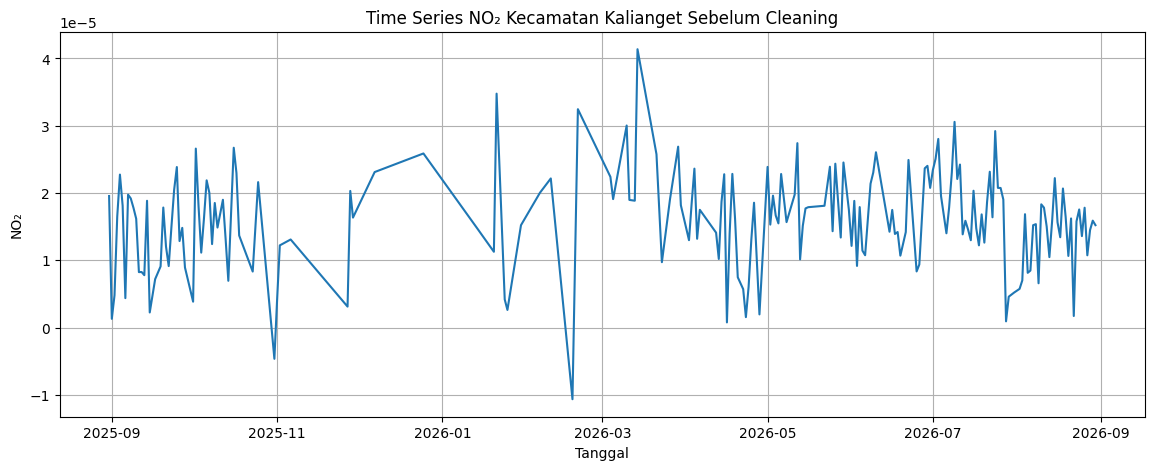

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["NO2"])
plt.title("Time Series NO₂ Kecamatan Kalianget Sebelum Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("NO₂")
plt.grid(True)
plt.show()

### 10.2 Deteksi Outlier Menggunakan IQR

Metode yang digunakan untuk mendeteksi outlier adalah Interquartile Range (IQR).

Rumus:

$$
IQR = Q3 - Q1
$$

Batas bawah:

$$
Q1 - 1.5(IQR)
$$

Batas atas:

$$
Q3 + 1.5(IQR)
$$

Nilai yang berada di luar batas tersebut dianggap sebagai outlier.

In [ ]:
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound)
)

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Batas bawah =", lower_bound)
print("Batas atas =", upper_bound)
print("Jumlah outlier =", outlier_mask.sum())

display(df.loc[outlier_mask, ["date", "NO2"]])

Q1 = 1.1894247904820077e-05
Q3 = 2.0112315951337223e-05
IQR = 8.218068046517146e-06
Batas bawah = -4.3285416495564277e-07
Batas atas = 3.243941802111294e-05
Jumlah outlier = 5


,date,NO2
46,2025-10-31,-0.000005
57,2026-01-21,0.000035
63,2026-02-18,-0.000011
64,2026-02-20,0.000032
70,2026-03-14,0.000041


### 10.3 Menangani Outlier

Outlier tidak langsung dihapus karena data ini merupakan time series. Nilai outlier diubah menjadi `NaN`, kemudian akan diisi menggunakan interpolasi berdasarkan waktu.

In [ ]:
df_clean = df.copy()

df_clean.loc[outlier_mask, "NO2"] = np.nan

print("Jumlah missing setelah outlier ditandai:",
      df_clean["NO2"].isna().sum())

Jumlah missing setelah outlier ditandai: 5


### 10.4 Imputasi Missing Value

Missing value diisi menggunakan interpolasi waktu. Untuk nilai kosong yang berada di awal atau akhir data, digunakan `ffill()` dan `bfill()` sebagai pengaman.

In [ ]:
df_clean = (
    df_clean
    .set_index("date")
    .interpolate(method="time")
    .ffill()
    .bfill()
    .reset_index()
)

print("Jumlah missing setelah imputasi:",
      df_clean["NO2"].isna().sum())

Jumlah missing setelah imputasi: 0


### 10.5 Pemeriksaan Setelah Cleaning

Data diperiksa kembali untuk memastikan tidak terdapat missing value dan outlier berdasarkan metode IQR.

In [ ]:
Q1_final = df_clean["NO2"].quantile(0.25)
Q3_final = df_clean["NO2"].quantile(0.75)
IQR_final = Q3_final - Q1_final

lower_final = Q1_final - 1.5 * IQR_final
upper_final = Q3_final + 1.5 * IQR_final

final_outlier_mask = (
    (df_clean["NO2"] < lower_final) |
    (df_clean["NO2"] > upper_final)
)

jumlah_missing_final = df_clean["NO2"].isna().sum()
jumlah_outlier_final = final_outlier_mask.sum()

print("==============================================")
print("HASIL PEMERIKSAAN DATA SETELAH CLEANING")
print("==============================================")
print("Missing value :", jumlah_missing_final)
print("Outlier       :", jumlah_outlier_final)

if jumlah_missing_final == 0 and jumlah_outlier_final == 0:
    print("Data sudah bersih dan siap untuk ekstraksi TSFEL.")
else:
    print("Masih terdapat data yang perlu diperiksa.")

HASIL PEMERIKSAAN DATA SETELAH CLEANING
Missing value : 0
Outlier       : 0
Data sudah bersih dan siap untuk ekstraksi TSFEL.


### 10.6 Visualisasi Data Setelah Cleaning

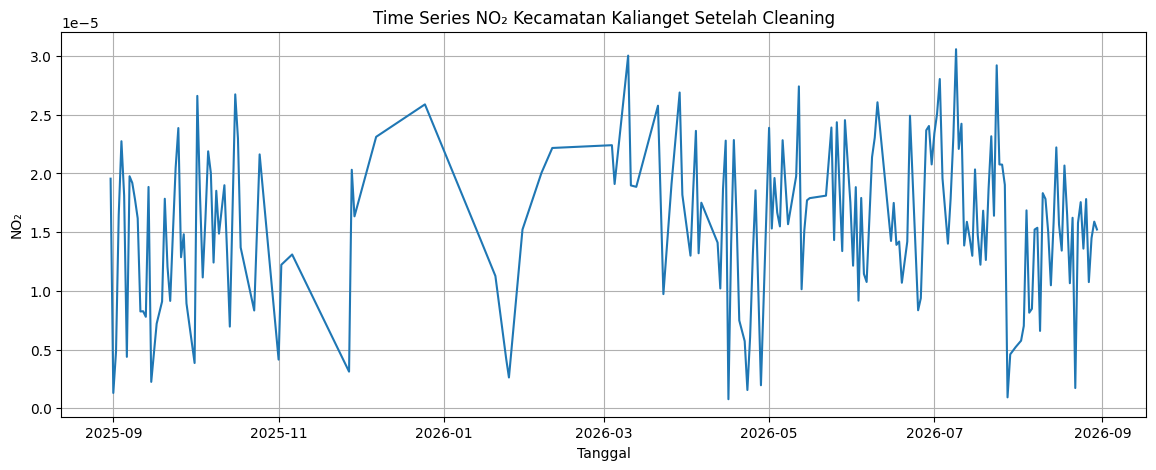

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean["date"], df_clean["NO2"])
plt.title("Time Series NO₂ Kecamatan Kalianget Setelah Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("NO₂")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import files

nama_file = "NO2_Kalianget_clean.csv"

df_clean.to_csv(
    nama_file,
    index=False,
    encoding="utf-8-sig"
)

print("Data bersih disimpan sebagai:", nama_file)

files.download(nama_file)

Data bersih disimpan sebagai: NO2_Kalianget_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Ekstraksi Fitur Menggunakan TSFEL

Setelah data NO₂ bersih, data digunakan untuk ekstraksi fitur menggunakan library TSFEL (Time Series Feature Extraction Library).

Pada tugas ini digunakan daftar 68 fitur yang telah ditentukan.

In [ ]:
pip install tsfel

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2_Kalianget_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Kalianget_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


### 11.1 Pemeriksaan Hasil Ekstraksi

In [ ]:
FINAL_CSV = "NO2_Kalianget_TSFEL.csv"

check_csv = pd.read_csv(FINAL_CSV)

print("File          :", FINAL_CSV)
print("Shape         :", check_csv.shape)
print("Kolom pertama :", check_csv.columns[0])
print("Kolom terakhir:", check_csv.columns[-1])

if check_csv.shape != (1, 68):
    raise ValueError(f"Shape salah: {check_csv.shape}; seharusnya (1, 68). Periksa kembali Bagian 4.")

print("\nFile final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.")

files.download(FINAL_CSV)

print("Unduhan dimulai:", FINAL_CSV, "-- JANGAN diubah/di-edit setelah ini.")

File          : NO2_Kalianget_TSFEL.csv
Shape         : (1, 68)
Kolom pertama : abs_energy
Kolom terakhir: zero_cross

File final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: NO2_Kalianget_TSFEL.csv -- JANGAN diubah/di-edit setelah ini.


## 12. Pengelompokan 68 Fitur TSFEL Berdasarkan Domain

Setelah proses preprocessing data NO₂ Kecamatan Kalianget dilakukan, yaitu deteksi outlier dan imputasi missing value, data kemudian diekstraksi menggunakan library TSFEL (Time Series Feature Extraction Library).

Hasil ekstraksi menghasilkan 68 fitur. Fitur-fitur tersebut dapat dikelompokkan ke dalam tiga domain, yaitu:

1. Statistical Domain
2. Temporal Domain
3. Spectral Domain


### 12.1 Statistical Domain

Statistical Domain berisi fitur yang menggambarkan karakteristik statistik dari nilai data NO₂. Fitur pada domain ini digunakan untuk melihat ukuran pemusatan, penyebaran, distribusi, serta perubahan nilai secara statistik.

 Daftar fitur Statistical Domain

| No | Fitur |
|---:|---|
| 1 | `abs_energy` |
| 2 | `average_power` |
| 3 | `calc_max` |
| 4 | `calc_mean` |
| 5 | `calc_median` |
| 6 | `calc_min` |
| 7 | `calc_std` |
| 8 | `calc_var` |
| 9 | `ecdf` |
| 10 | `ecdf_percentile` |
| 11 | `ecdf_percentile_count` |
| 12 | `ecdf_slope` |
| 13 | `hist_mode` |
| 14 | `interq_range` |
| 15 | `kurtosis` |
| 16 | `mean_abs_deviation` |
| 17 | `mean_abs_diff` |
| 18 | `mean_diff` |
| 19 | `median_abs_deviation` |
| 20 | `median_abs_diff` |
| 21 | `median_diff` |
| 22 | `mse` |
| 23 | `rms` |
| 24 | `skewness` |
| 25 | `sum_abs_diff` |

Jumlah Statistical Domain = 25 fitur

**Penjelasan**

Fitur statistik digunakan untuk mengetahui bagaimana karakteristik nilai NO₂ dalam data. Contohnya:

- `calc_mean` digunakan untuk menghitung nilai rata-rata NO₂.
- `calc_median` digunakan untuk mencari nilai tengah.
- `calc_std` digunakan untuk mengetahui tingkat penyebaran data terhadap rata-rata.
- `calc_min` dan `calc_max` digunakan untuk mengetahui nilai minimum dan maksimum.
- `kurtosis` digunakan untuk melihat bentuk distribusi data berdasarkan tingkat keruncingannya.
- `skewness` digunakan untuk mengetahui kemencengan distribusi data.
- `rms` digunakan untuk menghitung nilai root mean square.
- `interq_range` digunakan untuk mengetahui rentang antara kuartil pertama dan kuartil ketiga.

Dengan demikian, domain statistik memberikan gambaran mengenai distribusi dan karakteristik nilai NO₂.


### 12.2 Temporal Domain

Temporal Domain berisi fitur yang menganalisis pola dan perubahan data berdasarkan urutan waktu. Karena data NO₂ merupakan data time series, domain ini digunakan untuk melihat hubungan antarwaktu, perubahan nilai, pola naik-turun, dan karakteristik temporal lainnya.

Daftar fitur Temporal Domain

| No | Fitur |
|---:|---|
| 1 | `auc` |
| 2 | `autocorr` |
| 3 | `calc_centroid` |
| 4 | `dfa` |
| 5 | `distance` |
| 6 | `entropy` |
| 7 | `higuchi_fractal_dimension` |
| 8 | `human_range_energy` |
| 9 | `hurst_exponent` |
| 10 | `lempel_ziv` |
| 11 | `maximum_fractal_length` |
| 12 | `negative_turning` |
| 13 | `neighbourhood_peaks` |
| 14 | `petrosian_fractal_dimension` |
| 15 | `pk_pk_distance` |
| 16 | `positive_turning` |
| 17 | `slope` |
| 18 | `zero_cross` |

Jumlah Temporal Domain = 18 fitur

**Penjelasan**

Fitur temporal digunakan untuk melihat karakteristik data berdasarkan urutan waktunya.

Contohnya:

- `autocorr` digunakan untuk melihat hubungan antara nilai pada suatu waktu dengan nilai pada waktu sebelumnya.
- `slope` digunakan untuk melihat kecenderungan kenaikan atau penurunan data.
- `auc` menghitung luas area di bawah kurva time series.
- `positive_turning` menghitung karakteristik perubahan arah positif.
- `negative_turning` menghitung karakteristik perubahan arah negatif.
- `neighbourhood_peaks` digunakan untuk mendeteksi pola puncak pada data.
- `zero_cross` menghitung jumlah perubahan tanda yang melewati titik nol.
- `hurst_exponent` digunakan untuk melihat karakteristik ketergantungan atau pola jangka panjang dalam time series.
- `dfa` digunakan untuk menganalisis karakteristik korelasi jangka panjang pada data.

Dengan demikian, domain temporal memberikan informasi mengenai pola dan perubahan NO₂ berdasarkan urutan waktu.


### 12.3 Spectral Domain

Spectral Domain berisi fitur yang menganalisis data berdasarkan komponen frekuensi. Domain ini digunakan untuk mengetahui pola periodik, distribusi energi, dan karakteristik sinyal NO₂ pada berbagai frekuensi.

Daftar fitur Spectral Domain

| No | Fitur |
|---:|---|
| 1 | `fundamental_frequency` |
| 2 | `lpcc` |
| 3 | `max_frequency` |
| 4 | `max_power_spectrum` |
| 5 | `median_frequency` |
| 6 | `mfcc` |
| 7 | `power_bandwidth` |
| 8 | `spectral_centroid` |
| 9 | `spectral_decrease` |
| 10 | `spectral_distance` |
| 11 | `spectral_entropy` |
| 12 | `spectral_kurtosis` |
| 13 | `spectral_positive_turning` |
| 14 | `spectral_roll_off` |
| 15 | `spectral_roll_on` |
| 16 | `spectral_skewness` |
| 17 | `spectral_slope` |
| 18 | `spectral_spread` |
| 19 | `spectral_variation` |
| 20 | `spectrogram_mean_coeff` |
| 21 | `wavelet_abs_mean` |
| 22 | `wavelet_energy` |
| 23 | `wavelet_entropy` |
| 24 | `wavelet_std` |
| 25 | `wavelet_var` |

Jumlah Spectral Domain = 25 fitur

**Penjelasan**

Fitur spectral digunakan untuk menganalisis sinyal NO₂ dari sisi frekuensi.

Contohnya:

- `fundamental_frequency` menunjukkan frekuensi dasar dari sinyal.
- `max_frequency` menunjukkan frekuensi maksimum yang terdapat pada data.
- `max_power_spectrum` menunjukkan nilai daya spektrum maksimum.
- `spectral_centroid` menggambarkan pusat distribusi energi pada spektrum frekuensi.
- `spectral_entropy` mengukur tingkat ketidakaturan distribusi energi pada frekuensi.
- `spectral_kurtosis` menggambarkan keruncingan distribusi spektrum.
- `spectral_skewness` menunjukkan kemencengan distribusi spektrum.
- `spectral_roll_off` menunjukkan batas frekuensi yang mencakup sebagian besar energi spektrum.
- `wavelet_energy` menghitung energi berdasarkan transformasi wavelet.
- `wavelet_entropy` mengukur ketidakaturan distribusi energi wavelet.

Dengan demikian, domain spectral memberikan informasi mengenai karakteristik frekuensi dan energi pada data NO₂.


### 12.4 Rekapitulasi 68 Fitur

| Domain | Jumlah Fitur |
|---|---:|
| Statistical | 25 |
| Temporal | 18 |
| Spectral | 25 |
| **Total** | **68** |

Perhitungan:

$$
25 + 18 + 25 = 68
$$

Jadi, hasil ekstraksi data NO₂ menghasilkan 68 fitur, yang terdiri dari:

- 25 fitur Statistical
- 18 fitur Temporal
- 25 fitur Spectral


### 12.5 Hubungan dengan Data NO₂ Kecamatan Kalianget

Pada penelitian ini, data yang digunakan adalah data konsentrasi NO₂ (Nitrogen Dioxide) pada Kecamatan Kalianget.

Sebelum ekstraksi fitur dilakukan, data terlebih dahulu melalui tahap preprocessing, yaitu:

1. Mengambil data NO₂ berdasarkan wilayah Kecamatan Kalianget.
2. Menentukan periode data.
3. Melakukan deteksi outlier menggunakan metode Interquartile Range (IQR).
4. Mengubah nilai outlier menjadi missing value (`NaN`).
5. Melakukan imputasi missing value menggunakan interpolasi berdasarkan waktu.
6. Melakukan `forward fill` dan `backward fill` sebagai pelengkap.
7. Memastikan tidak terdapat missing value.
8. Memastikan tidak terdapat outlier.
9. Melakukan ekstraksi fitur menggunakan TSFEL.
10. Menghasilkan 68 fitur.

Setelah preprocessing selesai, data dinyatakan bersih dan dapat digunakan untuk proses ekstraksi fitur.
